In [1]:
from pathlib import Path
from functools import partial

import sympy
import symengine
import numpy as np
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis, normaltest
import matplotlib.pyplot as plt

from make_and_load_models import (
    get_timeseries_and_KM,
    load_timeseries,
    load_and_stack_timeseries,
)
from kramersmoyal import km
from utils import sindy_model, jeffreys_divergence

from mpl_toolkits.axisartist import Axes  # typing

In [6]:
np.random.random((12, 7, 5)).transpose((1, 0, 2)).shape

(7, 12, 5)

In [ ]:
SCRATCH_PATH = Path(f"/home/zachuu/scratch/ep0_m5_ms_1.3")
SCRATCH_PATH.mkdir(parents=True, exist_ok=True)
FIG_PATH = SCRATCH_PATH

In [ ]:
NUM_MODELS = 10

dt = 0.001
xi0 = [-0.016, 1.3, -1, 1e-5 / 2, 1e-1 / 2]
coeffs = [0, xi0[0], 0, xi0[1], xi0[2]]
ep0 = xi0[-2] * 2
ep1 = xi0[-1] * 2
num_bins = 100
target_metadata = {
    "num_datapoints": 10_000_000,
    "dt": dt,
    "EVEN_ABS": True,
    "coeffs": coeffs,
    "ep0": ep0,
    "ep1": ep1,
    "x0": 0.0,
    "num_bins": num_bins,
}

centers, pdf_stack, moment_1_stack, moment_2_stack = get_timeseries_and_KM(
    SCRATCH_PATH,
    target_metadata,
    NUM_DATASETS=NUM_MODELS,
    NUM_VALIDATION_DATASETS=1,
    NUM_CPUS=11,
)
time_stack, x_stack = load_and_stack_timeseries(SCRATCH_PATH, 10)

dx_stack = x_stack[:, 1:] - x_stack[:, :-1]
x_stack = x_stack[:, :-1]
time_stack = time_stack[:, :-1]
data_skip = 100
dx_stack = dx_stack[:, ::data_skip]
x_stack = x_stack[:, ::data_skip]
time_stack = time_stack[:, ::data_skip]

mask = (centers > -2.6) * (centers < 2.6)
centers = centers[mask]
num_bins = len(centers)
pdf_stack = pdf_stack[:, mask]
moment_1_stack = moment_1_stack[:, mask]
moment_2_stack = moment_2_stack[:, mask]

moment_1_mean = np.mean(moment_1_stack, axis=0)
moment_1_var = np.std(moment_1_stack, axis=0, mean=moment_1_mean)
# moment_1_var = np.ones_like(moment_1_var)
moment_2_mean = np.mean(moment_2_stack, axis=0)
moment_2_var = np.std(moment_2_stack, axis=0, mean=moment_1_mean)
# moment_2_var = np.ones_like(moment_2_var)

moment_1_weights = 1 / np.pow(moment_1_var, 1)
moment_1_weights /= np.sum(moment_1_weights)
moment_2_weights = 1 / np.pow(moment_2_var, 1)
moment_2_weights /= np.sum(moment_2_weights)

# validation_time, validation_x = load_timeseries(SCRATCH_PATH / "validation_0.npz")
# validation_dx = validation_x[1:] - validation_x[:-1]
# validation_x = validation_x[:-1]
# N = 10
# validation_time = validation_time[:-1:N]
# validation_dx = validation_dx[::N]
# validation_x = validation_x[::N]
# 5 std
norm_dist_x_edges, norm_dist_dx = np.linspace(
    -5 * np.sqrt(dt), 5 * np.sqrt(dt), 501, retstep=True
)
norm_dist_x = (norm_dist_x_edges[1:] + norm_dist_x_edges[:-1]) / 2
normal_dist = np.exp(-(norm_dist_x**2) / (2 * dt))
normal_dist /= np.sum(normal_dist * norm_dist_dx)

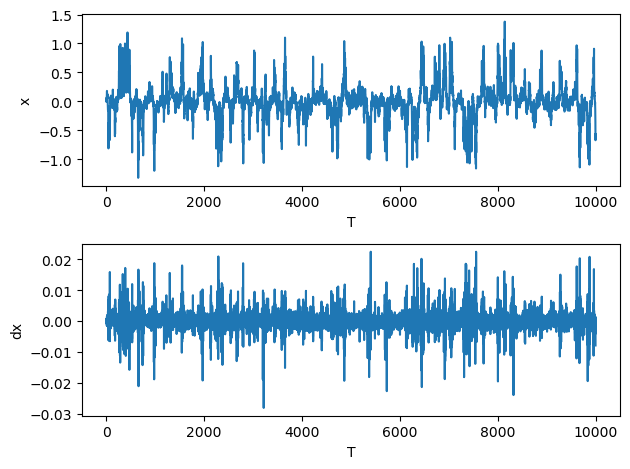

In [ ]:
for i in range(NUM_MODELS):
    fig, (ax, ax2) = plt.subplots(2)
    ax.plot(time_stack[0, ::10], x_stack[0, ::10])
    ax.set_xlabel("T")
    ax.set_ylabel("x")
    ax2.plot(time_stack[0, ::10], dx_stack[0, ::10])
    ax2.set_xlabel("T")
    ax2.set_ylabel("dx")
    fig.tight_layout()
    fig.savefig(FIG_PATH / f"dataset_{i}.png")

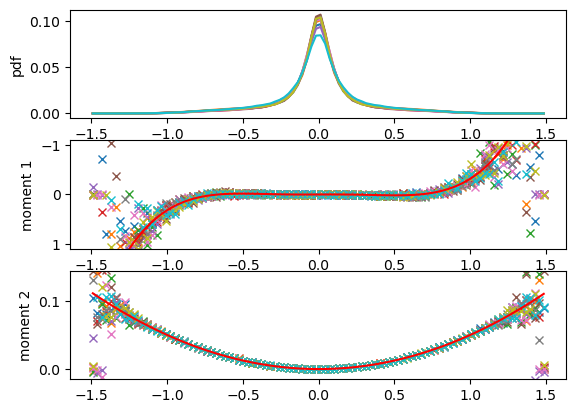

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3)

ax1.plot(centers, pdf_stack.T)
ax1.set_ylabel("pdf")

ax2.plot(centers, moment_1_stack.T, linestyle="", marker="x")
ax2.plot(
    centers,
    xi0[0] * centers + xi0[1] * centers**3 + xi0[2] * centers**3 * np.abs(centers),
    c="r",
)
ax2.set_ylabel("moment 1")
x = 1.25
ax2.set_ylim(
    top=xi0[0] * x + xi0[1] * x**3 + xi0[2] * x**3 * np.abs(x),
    bottom=xi0[0] * (-x) + xi0[1] * (-x) ** 3 + xi0[2] * (-x) ** 3 * np.abs(-x),
)

ax3.plot(centers, moment_2_stack.T, linestyle="", marker="x")
ax3.plot(centers, xi0[3] + xi0[4] * (centers**2), c="r")
ax3.set_ylabel("moment 2")
x = 1.7
ax3.set_ylim(top=xi0[3] + xi0[4] * (x**2), bottom=-(xi0[3] + xi0[4] * (x**2)) / 10)

fig.savefig(SCRATCH_PATH / "models.png")

In [ ]:
x_sym = sympy.symbols("x")

arr = []
for i in range(6):
    if i % 2 == 0 and i != 0:
        arr.append(
            x_sym ** (i - 1)
            * symengine.Abs(x_sym)
            / np.prod(range(1, i + 1), initial=1)
        )
    else:
        arr.append(x_sym**i / np.prod(range(1, i + 1), initial=1))
A_lib_expr = np.array(arr)
num_A_expr = len(A_lib_expr)

lib_A = np.empty((num_A_expr, num_bins))
lib_A_dist_stack = np.empty((num_A_expr, *x_stack.shape))  # (5, 10, 1_000_000)
for k in range(num_A_expr):
    lamb_expr = sympy.lambdify(x_sym, A_lib_expr[k])
    lib_A[k] = lamb_expr(centers)
    lib_A_dist_stack[k] = lamb_expr(x_stack)

arr = []
for i in range(5):
    if i % 2 == 1 and i != 0:
        arr.append(
            x_sym ** (i - 1)
            * symengine.Abs(x_sym)
            / np.prod(range(1, i + 1), initial=1)
        )
    else:
        arr.append(x_sym**i / np.prod(range(1, i + 1), initial=1))
C_lib_expr = np.array(arr)
# C_lib_expr = np.array([x_sym**i for i in range(5)])
num_C_expr = len(C_lib_expr)

lib_C = np.empty((num_C_expr, num_bins))
lib_C_dist_stack = np.empty((num_C_expr, *x_stack.shape))  # (5, 10, 1_000_000)
for k in range(num_C_expr):
    lamb_expr = sympy.lambdify(x_sym, C_lib_expr[k])
    lib_C[k] = lamb_expr(centers)
    lib_C_dist_stack[k] = lamb_expr(x_stack)
print(C_lib_expr)
# print(lib_C.shape)
print(lib_C_dist_stack.shape)

[1.00000000000000 Abs(x) x**2/2 x**2*Abs(x)/6 x**4/24]
(5, 10, 100000)


In [ ]:
def cost_diffusion_stack(
    xi,
    lib_C,
    lib_C_dist_stack,
    diffusion_stack,
    dx_stack,
    alpha=0,
):
    if np.any(xi < 0):
        return np.inf
    dw_Q_stack = dx_stack / np.sqrt(2 * lib_C_dist_stack.transpose((1, 2, 0)) @ xi)
    # km for each trajectory separately?
    (dw_Q_hist,), _ = km(dw_Q_stack.flatten(), powers=0, bins=(norm_dist_x_edges,))
    dw_Q_hist /= np.sum(dw_Q_hist * norm_dist_dx)

    jef_dist = jeffreys_divergence(dw_Q_hist, normal_dist, dx=norm_dist_dx)
    return (1 - alpha) * jef_dist + alpha / 2 * np.sum(
        ((lib_C.T @ xi)[None, :] - diffusion_stack) ** 2  # Probably needs more
    )


def cost_drift_stack(
    xi,
    lib_A,
    lib_A_dist_stack,
    drift_stack,
    diffusion,
    dx_stack,
    beta=0,
):
    if np.any(xi < 0):
        return np.inf
    dw_P_stack = (dx_stack - lib_A_dist_stack.T @ xi * dt) / diffusion
    (dw_P_hist,), _ = km(dw_P_stack.flatten(), powers=0, bins=(norm_dist_x_edges,))
    dw_P_hist /= np.sum(dw_P_hist * norm_dist_dx)

    jef_dist = jeffreys_divergence(dw_P_hist, normal_dist, dx=norm_dist_dx)
    return (1 - beta) * jef_dist + beta / 2 * np.sum(
        ((lib_A.T @ xi)[None, :] - drift_stack) ** 2  # Probably needs more
    )

SSR Loop

In [ ]:
def callback(intermediate_result):
    print(intermediate_result.fun)


def opt_fun(xi_C_0, lib_C_dist_stack, dx_stack):
    res = minimize(
        partial(
            cost_diffusion_stack, lib_C_dist_stack=lib_C_dist_stack, dx_stack=dx_stack
        ),
        xi_C_0,
        method="nelder-mead",
    )
    return res.x, res.fun


import multiprocessing as mp

NUM_CPUS = 10
xi_C = np.ones(num_C_expr)
# xi_C = np.array([1e-3 / 2, 1e-6, 0.1 / 2, 1e-6, 1e-6])
lib_C_dist_stack_copy = lib_C_dist_stack.copy()
C_lib_expr_copy = C_lib_expr.copy()

minimum_Xis = np.zeros((num_C_expr, num_C_expr), dtype=xi_C.dtype)
minimum_Vs = np.full((num_C_expr), np.inf)

minimum_Xis[0], minimum_Vs[0] = opt_fun(xi_C, lib_C_dist_stack_copy, dx_stack)
print(f"Cost = {minimum_Vs[0]} from Xi = {minimum_Xis[0]}")
print(
    f"Active C: {sympy.sqrt(2 * sindy_model(minimum_Xis[0], C_lib_expr))}\n", flush=True
)

active = np.array(range(num_C_expr))
active_history = [active]
for k in range(1, num_C_expr):
    params_list = []
    valid_indices = []
    for j in range(1, len(active)):
        tmp_active = active.copy()
        tmp_active = np.delete(tmp_active, j)
        if len(tmp_active) == 0:  # not possible?
            continue

        xi_C_copy = xi_C[tmp_active]
        lib_C_dist_stack_copy_copy = lib_C_dist_stack_copy[tmp_active]
        params_list.append([xi_C_copy, lib_C_dist_stack_copy_copy, dx_stack])
        valid_indices.append(j)
    with mp.Pool(min(NUM_CPUS, len(params_list))) as p:
        results = p.starmap(opt_fun, params_list)
    Xis = []
    Vs = []
    for Xi, V in results:
        Xis.append(Xi)
        Vs.append(V)
    min_found = np.nanargmin(Vs)
    # min_found = np.nanargmin(jefs)
    min_idx = valid_indices[min_found]
    min_V = Vs[min_found]
    min_Xi = Xis[min_found]
    active = np.delete(active, min_idx)
    minimum_Vs[k] = min_V
    minimum_Xis[k, active] = min_Xi
    active_history.append(active)
    print(f"Cost = {min_V} from Xi = {min_Xi}")
    print(f"C: {sympy.sqrt(2 * sindy_model(min_Xi, C_lib_expr[active]))}\n", flush=True)

    # xi_C[active] = min_Xi

Cost = 1.0473584417359536 from Xi = [1.04456938e-03 3.42209265e-07 9.44283275e-01 2.17408931e+00
 1.26599890e+00]
Active C: sqrt(0.105499908417461*x**4 + 0.724696437234131*x**2*Abs(x) + 0.944283275428016*x**2 + 6.84418529094862e-7*Abs(x) + 0.00208913875607554)

Cost = 0.023549365346235702 from Xi = [1.61151846e-10 1.04012993e+00 1.33434402e+00 1.20937769e+00]
C: sqrt(0.100781473892913*x**4 + 0.444781341583224*x**2*Abs(x) + 1.04012992567768*x**2 + 3.22303691435781e-10)

Cost = 0.0036226619615635134 from Xi = [5.33774936e-04 1.24061311e+00 1.27162930e+00]
C: sqrt(0.105969108572327*x**4 + 0.413537703671041*x**2*Abs(x) + 0.00106754987224002)

Cost = 0.001619609359423399 from Xi = [6.38046595e-04 9.11438304e-01]
C: sqrt(0.303812767858459*x**2*Abs(x) + 0.00127609319096306)

Cost = 0.07910311042150753 from Xi = [0.00127563]
C: 0.0505100933601219



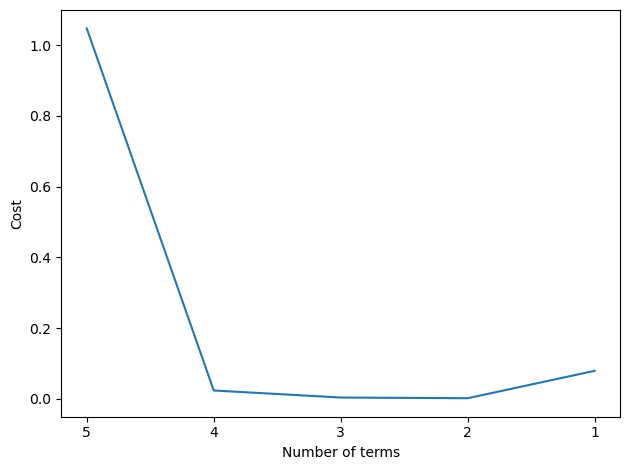

In [10]:
fig, ax = plt.subplots()
ax.plot(minimum_Vs)
ax.set_ylabel("Cost")
ax.set_xlabel("Number of terms")
ax.set_xticks(range(len(minimum_Vs)), labels=[str(x) for x in range(num_C_expr, 0, -1)])
fig.tight_layout()
fig.savefig(FIG_PATH / f"cost_vs_iteration.png")
plt.show()

MEAN: 3.0e-06
VARI: 2.2e-04
SKEW: -1.0e-02
KURT: 1.1e+00


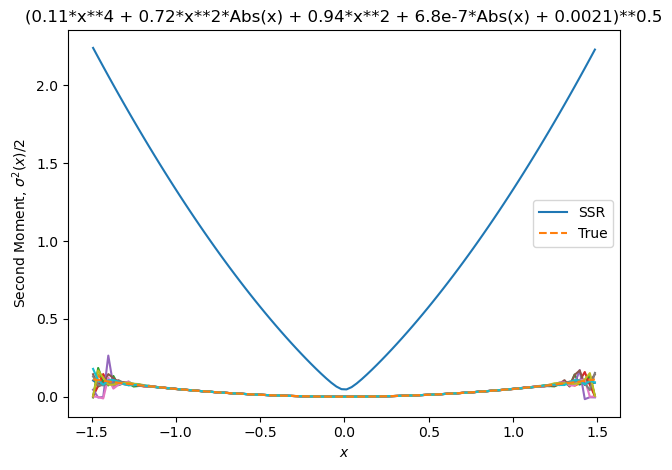

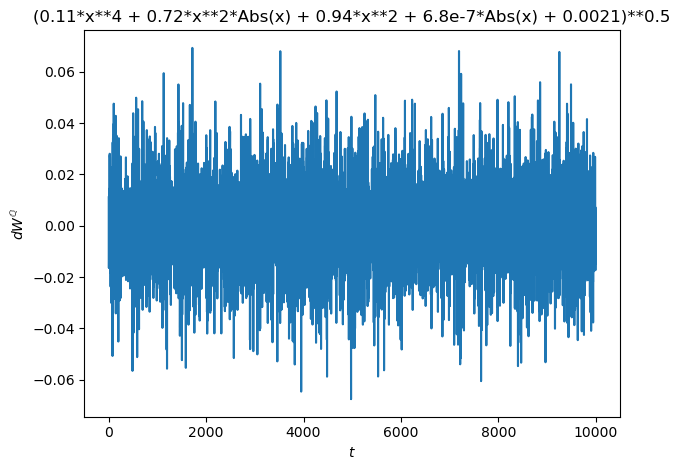

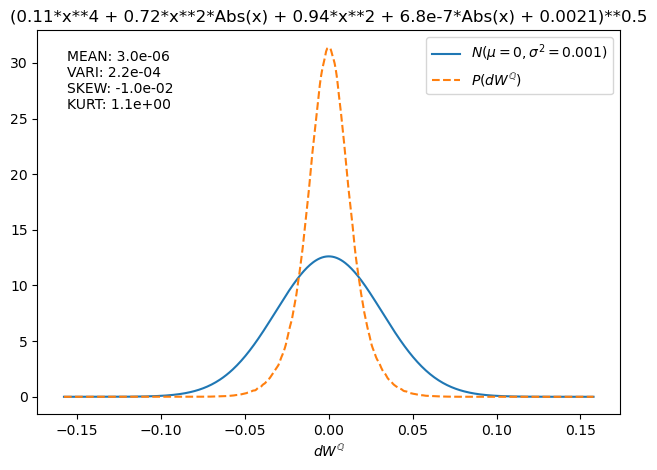

MEAN: 3.4e-04
VARI: 6.3e-01
SKEW: 1.4e+01
KURT: 7.7e+03


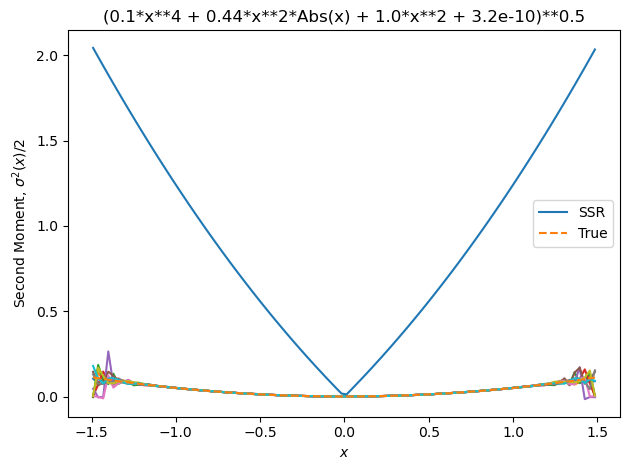

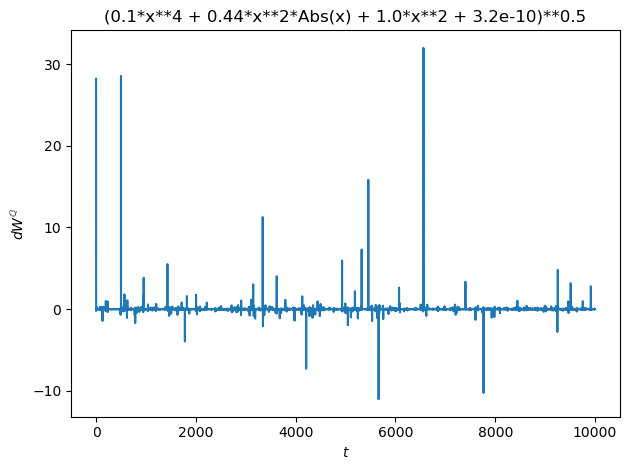

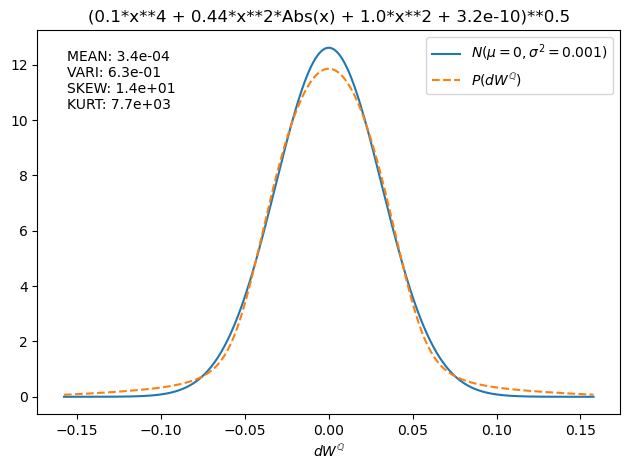

MEAN: 1.3e-05
VARI: 1.0e-03
SKEW: -2.2e-04
KURT: 2.8e-01


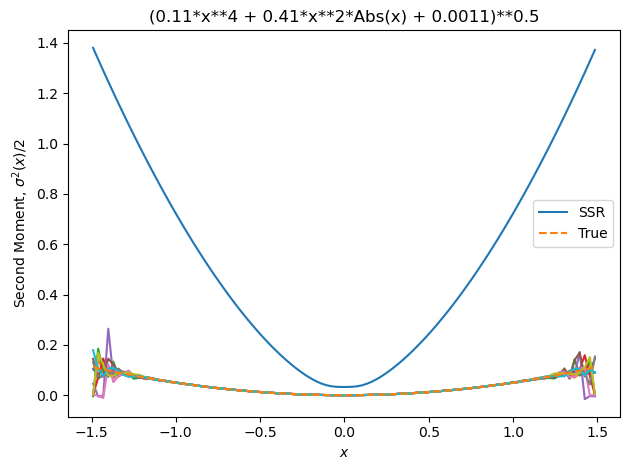

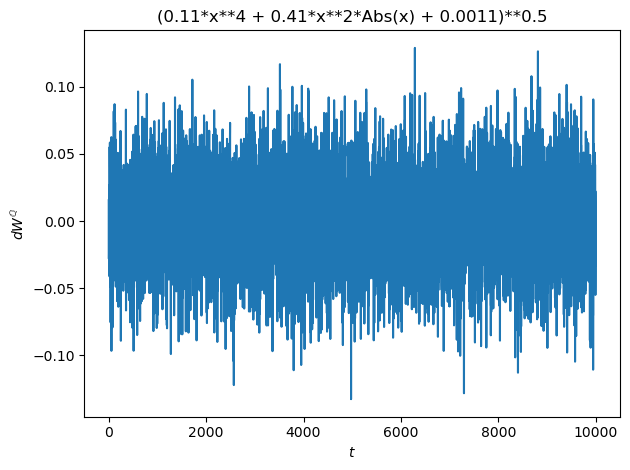

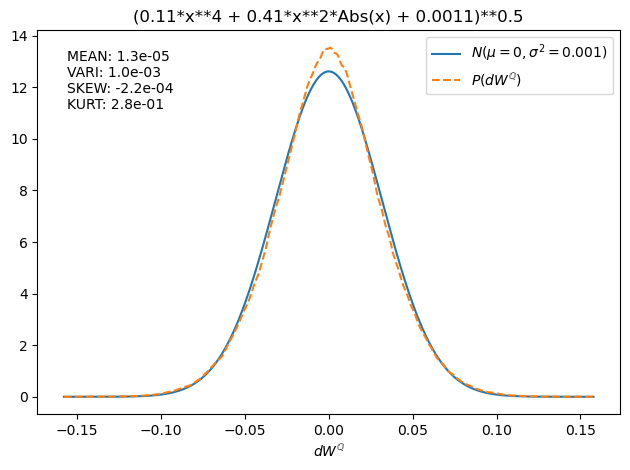

MEAN: 1.4e-05
VARI: 1.0e-03
SKEW: 3.0e-04
KURT: 2.1e-01


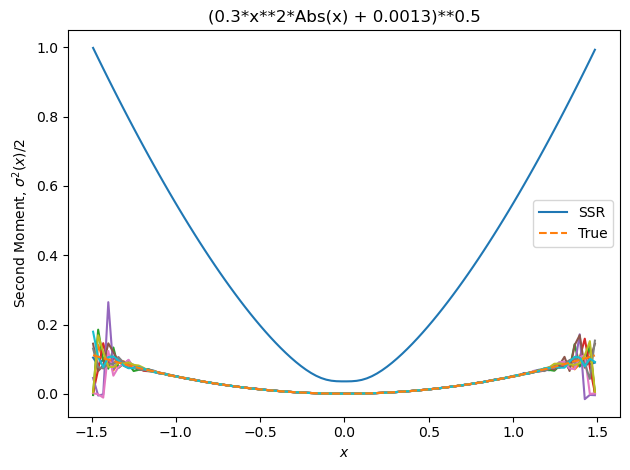

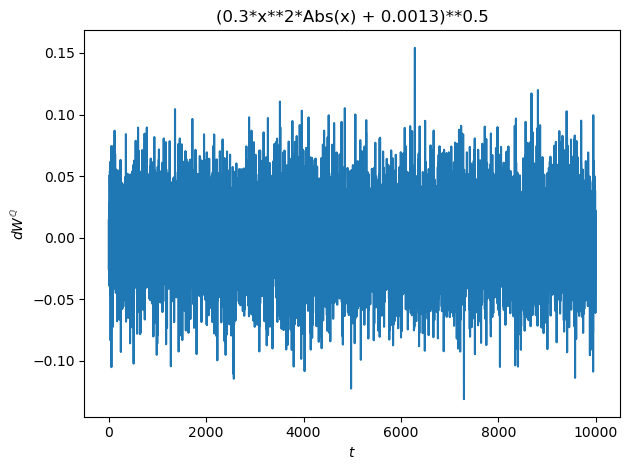

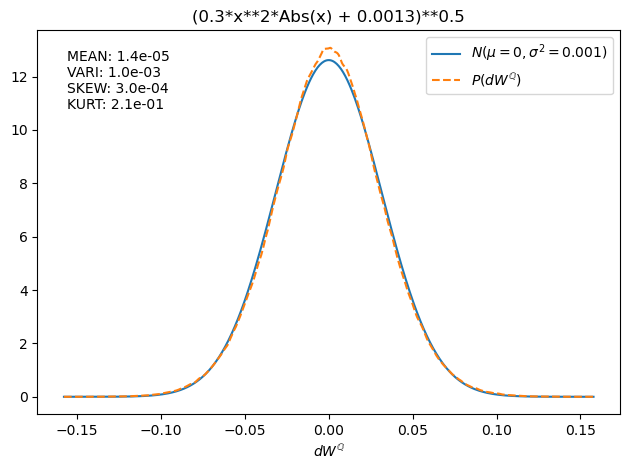

MEAN: 2.5e-05
VARI: 3.3e-03
SKEW: -2.3e-02
KURT: 1.1e+01


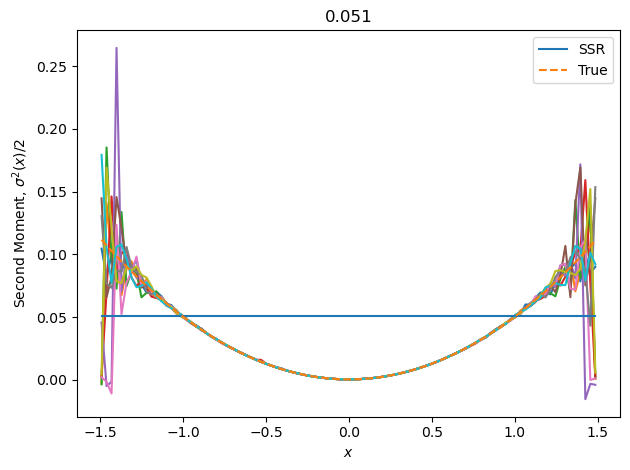

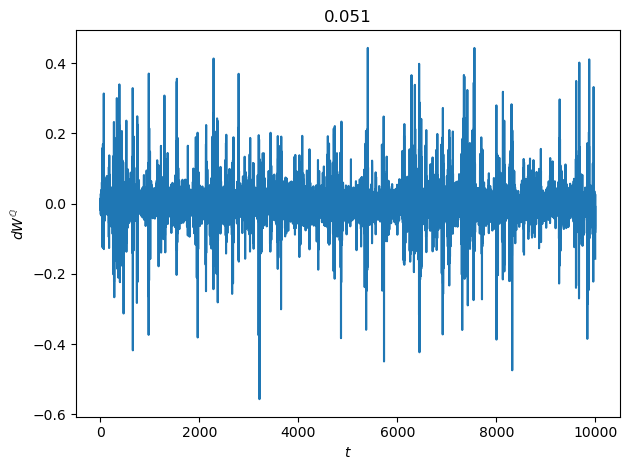

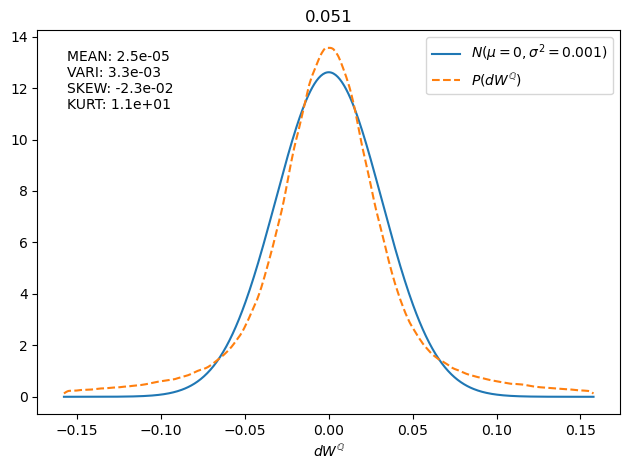

In [ ]:
for i in range(len(active_history)):
    tmp_active = active_history[i]
    num_terms = len(tmp_active)
    xi_bias = minimum_Xis[i][tmp_active]
    # sympy.N rounds all values to the Nth significant figure, unfortunately including the sqrt
    model = sympy.N(sympy.sqrt(2 * sindy_model(xi_bias, C_lib_expr[tmp_active])), 2)

    moment_2_ssr = sympy.lambdify(x_sym, model)(centers)
    if isinstance(moment_2_ssr, (float, int)):
        moment_2_ssr = np.full(centers.shape, moment_2_ssr)
    fig_moment_2, ax_moment_2 = plt.subplots()

    ax_moment_2.plot(centers, moment_2_stack.T)
    # ax_moment_2.plot(centers, moment_2_weights)
    ax_moment_2.plot(centers, moment_2_ssr[:, None], label="SSR")
    ax_moment_2.plot(
        centers, (xi0[-2] + xi0[-1] * centers**2), linestyle="--", label="True"
    )
    ax_moment_2.set_xlabel(r"$x$")
    ax_moment_2.set_ylabel(r"Second Moment, $\sigma^2(x)/2$")
    ax_moment_2.set_title(str(model))
    ax_moment_2.legend()
    fig_moment_2.tight_layout()
    fig_moment_2.savefig(FIG_PATH / f"moment_2_{num_terms}.png")

    dwQ_stack = dx_stack / (
        np.sqrt(2 * lib_C_dist_stack_copy[tmp_active].transpose((1, 2, 0)) @ xi_bias)
    )

    fig_dwQ, ax_dwQ = plt.subplots()
    ax_dwQ.plot(time_stack[0, ::10], dwQ_stack[0, ::10])
    ax_dwQ.set_ylabel(r"$dW^\mathbb{Q}$")
    ax_dwQ.set_xlabel(r"$t$")
    ax_dwQ.set_title(str(model))
    fig_dwQ.tight_layout()
    fig_dwQ.savefig(FIG_PATH / f"dwQ_{num_terms}.png")
    dwQ_flat = dwQ_stack.flatten()
    stats = f"MEAN: {np.mean(dwQ_flat):1.1e}\nVARI: {np.var(dwQ_flat):1.1e}\nSKEW: {skew(dwQ_flat):1.1e}\nKURT: {kurtosis(dwQ_flat):1.1e}"
    print(stats)
    (dwQ_hist_sindy,), _ = km(dwQ_flat, powers=0, bins=(norm_dist_x_edges,))
    dwQ_hist_sindy /= np.sum(dwQ_hist_sindy * norm_dist_dx)

    fig_norm_dist, ax_norm_dist = plt.subplots()
    ax_norm_dist.plot(norm_dist_x, normal_dist, label=rf"$N(\mu=0, \sigma^2={dt})$")
    ax_norm_dist.plot(
        norm_dist_x, dwQ_hist_sindy, linestyle="--", label=r"$P(dW^\mathbb{Q})$"
    )
    ax_norm_dist.text(
        x=0.05,
        y=0.95,
        s=stats,
        horizontalalignment="left",
        verticalalignment="top",
        transform=ax_norm_dist.transAxes,
    )
    ax_norm_dist.set_xlabel(r"$P(dW^\mathbb{Q})$")
    ax_norm_dist.set_xlabel(r"$dW^\mathbb{Q}$")
    ax_norm_dist.set_title(str(model))
    ax_norm_dist.legend()
    fig_norm_dist.tight_layout()
    fig_norm_dist.savefig(FIG_PATH / f"norm_dist_{num_terms}.png")

    plt.show()